In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("netflix_titles.csv (1).zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**#BASIC CLEANING**

In [5]:
df.shape

(8807, 12)

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
df.duplicated().sum()

0

**#DATA CLEANING**

In [19]:
df.drop_duplicates(inplace=True)

In [39]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added']=df['date_added'].dt.year

In [41]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

**##Q1. Movies vs TV Shows kitne hain?**

In [64]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

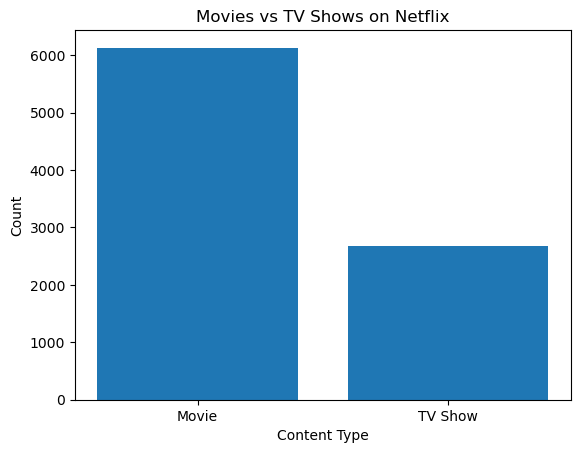

In [67]:
content_count = df['type'].value_counts()

plt.bar(content_count.index, content_count.values)
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

**##Q2. Top 10 countries kaun se hain jaha se Netflix content aata hai?**

In [122]:
top_country=df['country'].value_counts().head(10)
top_country

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

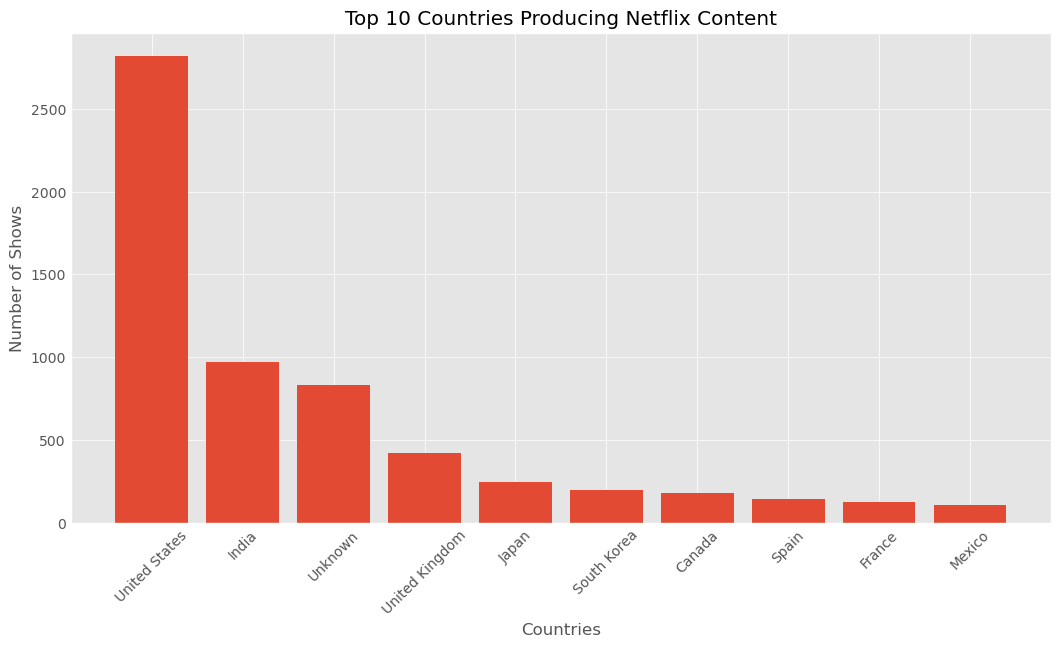

In [123]:
plt.figure(figsize=(10,5))

plt.bar(
    top_country.index,
    top_country.values
)

plt.xticks(rotation=45)
plt.xlabel("Countries")
plt.ylabel("Number of Shows")
plt.title("Top 10 Countries Producing Netflix Content")

plt.show()

**##Q3-Year-wise Netflix content growth kaisi hai?**

In [117]:
content_growth=df['year_added'].astype('Int64').value_counts().sort_index()
content_growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: Int64

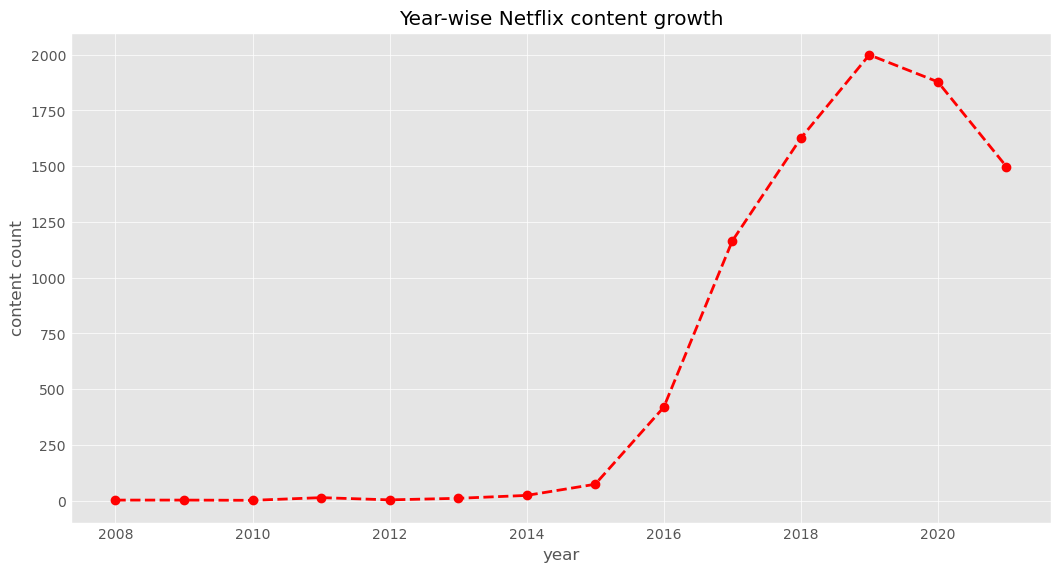

In [113]:
plt.figure(figsize=(10,5))
plt.style.use('ggplot')
plt.plot(content_growth.index,content_growth.values,'ro--')
plt.xlabel('year')
plt.ylabel('content count')
plt.title('Year-wise Netflix content growth')
plt.grid(True)

**##Q4. Top 10 ratings kaun si hain?**

In [156]:
top_rating=df['rating'].value_counts().head(10)
top_rating

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

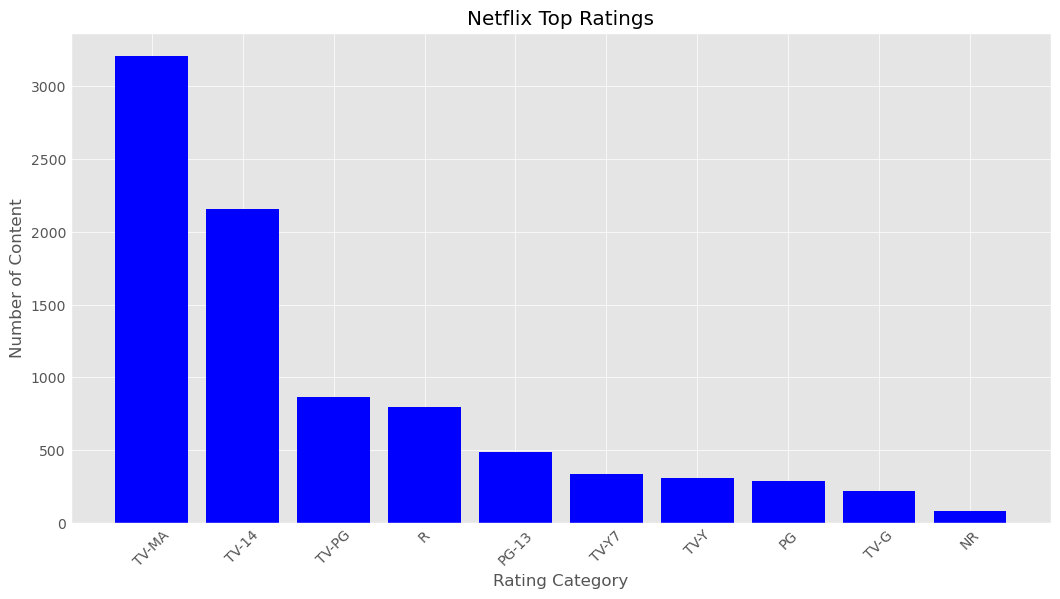

In [158]:
plt.style.use('ggplot')
plt.figure(figsize=(10,5))
plt.bar(top_rating.index,top_rating.values,color='blue')
plt.xticks(rotation=45)
plt.xlabel('Rating Category')
plt.ylabel('Number of Content')
plt.title("Netflix Top Ratings")
plt.grid(True)

**##Q5-Top 10 genres/categories kaun si hain?**

In [149]:
genres=df["listed_in"].str.split(",").explode().str.strip()
genres.unique()
top_genres=genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

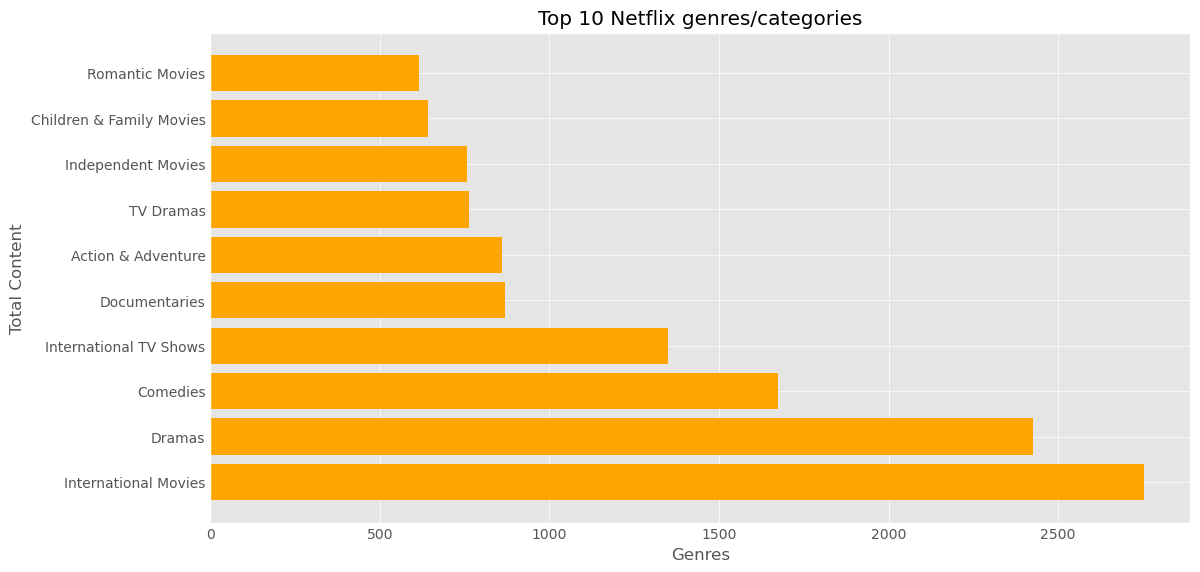

In [154]:
plt.figure(figsize=(10,5))
plt.barh(top_genres.index,top_genres.values,color='orange')
# plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('Total Content')
plt.title('Top 10 Netflix genres/categories')
plt.grid(True)

**##Q6: India ka Netflix content kitna hai**

In [193]:
# India content filter
india_content = df[df['country'].str.contains('India', na=False)]

# Movie vs TV Show count
india_type = india_content['type'].value_counts()

india_type

type
Movie      962
TV Show     84
Name: count, dtype: int64

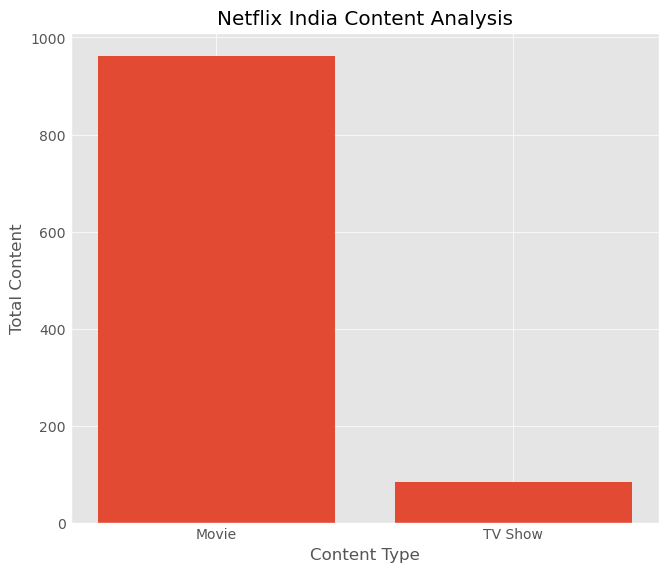

In [194]:
plt.figure(figsize=(6,5))

plt.bar(
    india_type.index,
    india_type.values
)

plt.xlabel("Content Type")
plt.ylabel("Total Content")
plt.title("Netflix India Content Analysis")

plt.grid(True)

plt.show()

*Indian Netflix content is highly dominated by Movies compared to TV Shows.*

In [195]:
india_genres = india_content['listed_in'].str.split(',').explode().str.strip()

india_genres.value_counts().head(10)

listed_in
International Movies      864
Dramas                    662
Comedies                  323
Independent Movies        167
Action & Adventure        137
Romantic Movies           120
Music & Musicals           96
Thrillers                  92
International TV Shows     66
Horror Movies              35
Name: count, dtype: int64

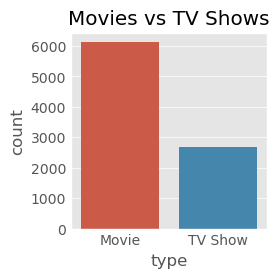

In [196]:
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.show()

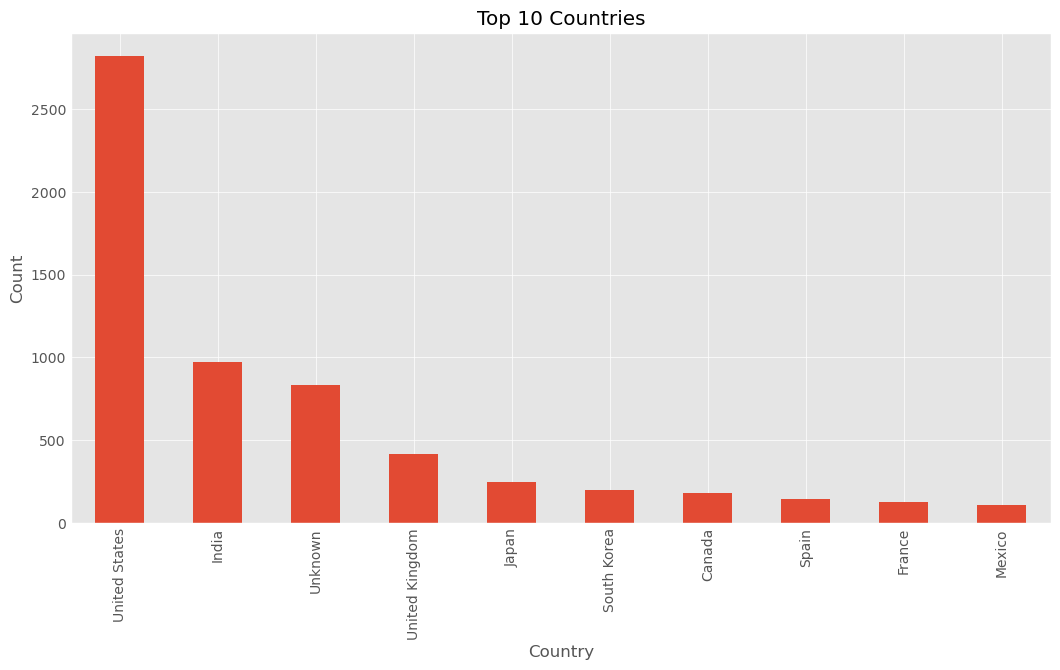

In [197]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

- Insight 1: Netflix par Movies ki quantity TV Shows se zyada hai.
- Insight 2: United States ka content sabse zyada hai.
- Insight 3: 2015 ke baad Netflix content rapidly increase hua.